# **Load Metadata**

In [20]:
import pandas as pd

metadata = pd.read_csv('brugada-syndrome/metadata.csv')
print(metadata.iloc[30:35])

    patient_id  basal_pattern  sudden_death  brugada
30      460919              0             0        2
31      461866              0             0        0
32      466796              0             0        0
33      471727              0             0        1
34      478457              0             0        0


# **Merging Label 2 and 1**

In [21]:
metadata['brugada'] = metadata['brugada'].replace(2, 1)
print(metadata.iloc[30:35])
print(f"Total subjects: {len(metadata)}")
print(f"Brugada patients: {(metadata['brugada'] > 0).sum()}")
print(f"Healthy subjects: {(metadata['brugada'] == 0).sum()}")

    patient_id  basal_pattern  sudden_death  brugada
30      460919              0             0        1
31      461866              0             0        0
32      466796              0             0        0
33      471727              0             0        1
34      478457              0             0        0
Total subjects: 363
Brugada patients: 76
Healthy subjects: 287


# **Initial Visualization**

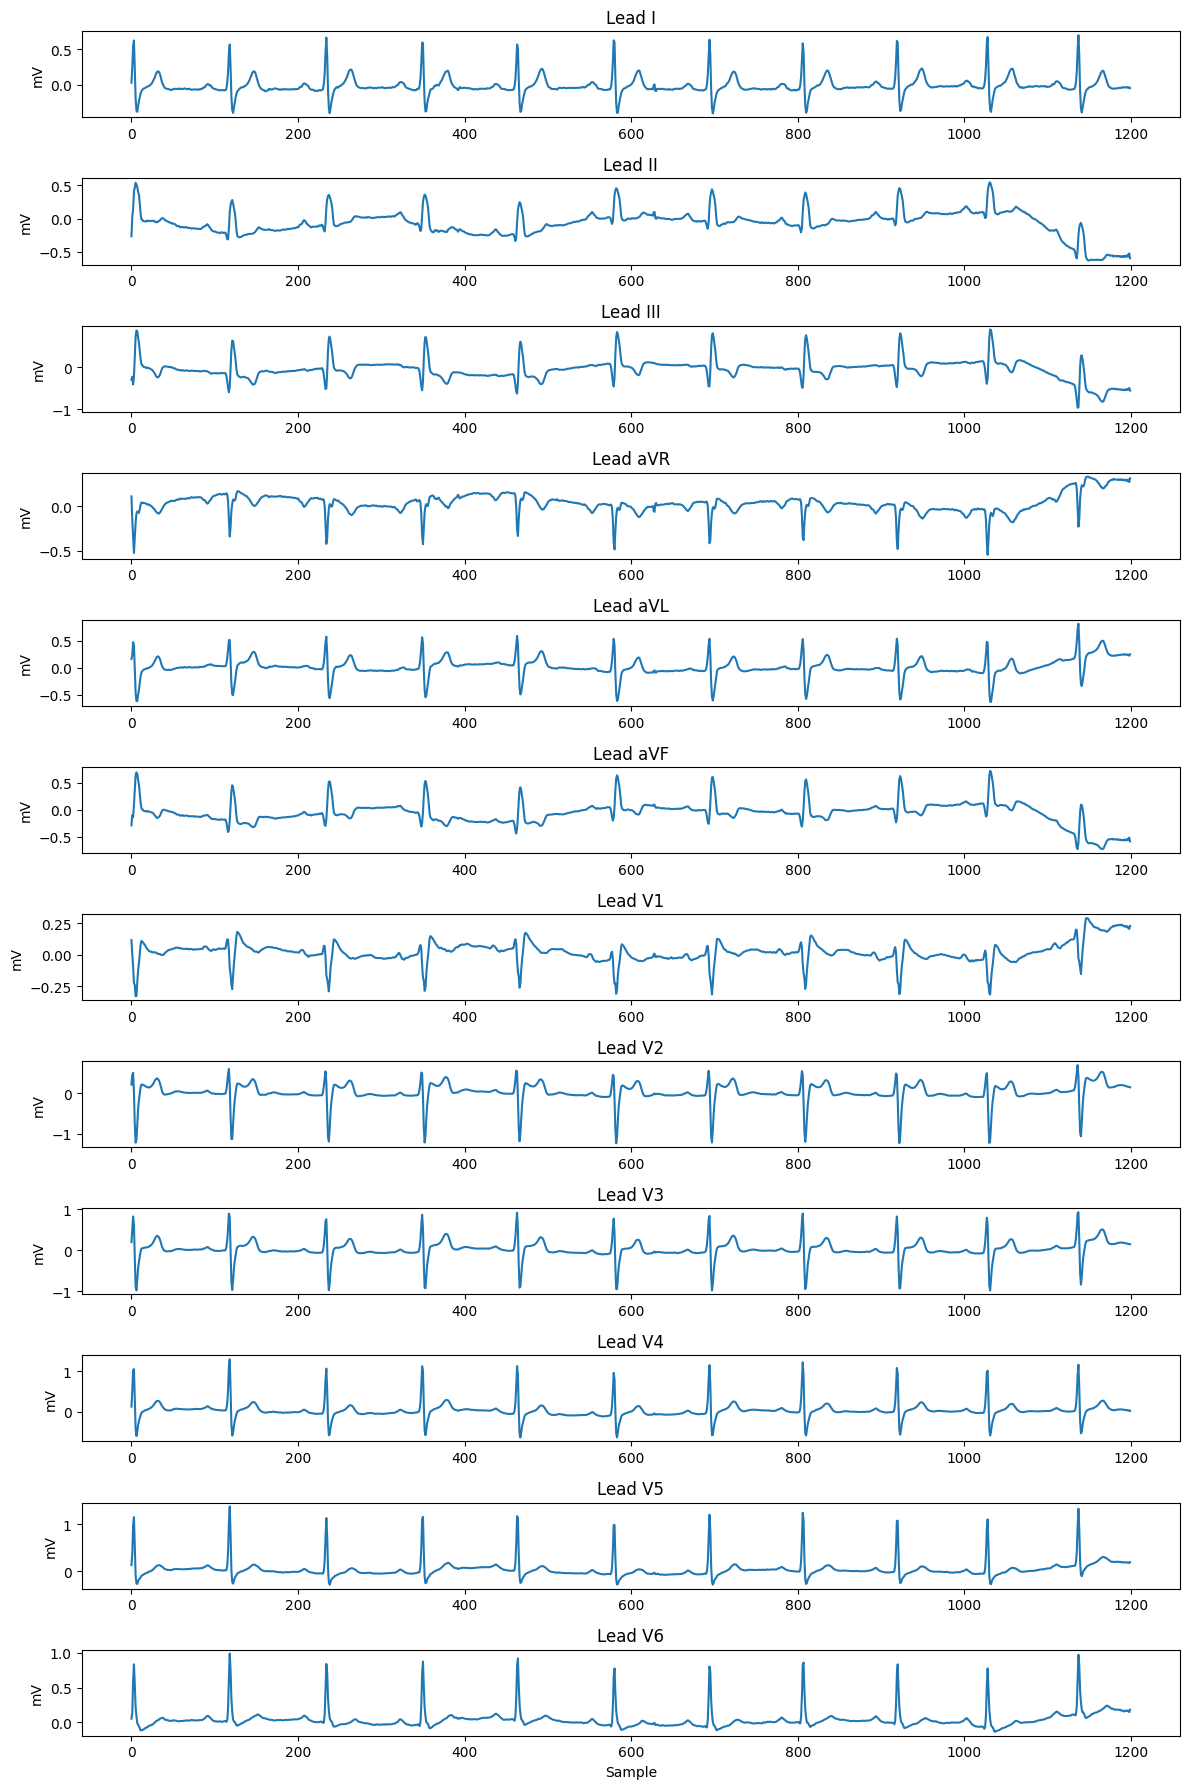

In [22]:
import wfdb
import matplotlib.pyplot as plt

patient_id = '188981'
record = wfdb.rdrecord(f'brugada-syndrome/files/{patient_id}/{patient_id}')

signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs

num_leads = len(lead_names)

plt.figure(figsize=(12, 18))

for i in range(num_leads):
    plt.subplot(num_leads, 1, i + 1)
    plt.plot(signals[:, i])
    plt.title(f'Lead {lead_names[i]}')
    plt.ylabel('mV')

plt.xlabel('Sample')
plt.tight_layout()
plt.show()

# **Filtering**

In [23]:
from scipy import signal

def signal_cleaning(raw_data):
    b, a = signal.butter(3, 0.05, btype='highpass', fs=100)
    return signal.filtfilt(b, a, raw_data)

clean_signal = signal_cleaning(signals[:, 0])

# **Feature Extraction**

In [24]:
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
import numpy as np

extracted_features = []
left_width = 40
right_width = 60
sample_id_counter = 0

for index, row in metadata.iterrows():
    p_id = str(row['patient_id'])
    is_brugada = row['brugada']

    try:
        record = wfdb.rdrecord(f'brugada-syndrome/files/{p_id}/{p_id}', channels=[1, 6, 7])
        signal_raw = record.p_signal

        norm_signals = np.zeros_like(signal_raw)

        for i in range(3):
            clean = signal_cleaning(signal_raw[:, i])
            # Norm 0-1
            if clean.max() != clean.min():
                norm_signals[:, i] = (clean - clean.min()) / (clean.max() - clean.min())
            else:
                norm_signals[:, i] = clean

        pks, _ = find_peaks(norm_signals[:, 0], distance=50, height=0.4)

        for p in pks:
            if p > left_width and (p + right_width) < len(norm_signals):
                snip = norm_signals[p - left_width : p + right_width, :]

                v1 = snip[:, 1]
                v2 = snip[:, 2]

                v1_feats = {
                    'v1_mean': np.mean(v1), 'v1_std': np.std(v1),
                    'v1_max': np.max(v1), 'v1_min': np.min(v1),
                    'v1_amplitude': np.max(v1) - np.min(v1),
                    'v1_skew': skew(v1), 'v1_kurtosis': kurtosis(v1)
                }

                v2_feats = {
                    'v2_mean': np.mean(v2), 'v2_std': np.std(v2),
                    'v2_max': np.max(v2), 'v2_min': np.min(v2),
                    'v2_amplitude': np.max(v2) - np.min(v2),
                    'v2_skew': skew(v2), 'v2_kurtosis': kurtosis(v2)
                }

                feature_row = {
                    'sample_id': f"SMPL_{sample_id_counter}",
                    'patient_id': p_id,
                    'label': 'Brugada' if is_brugada == 1 else 'Normal',
                    'label_code': is_brugada
                }
                feature_row.update(v1_feats)
                feature_row.update(v2_feats)

                extracted_features.append(feature_row)
                sample_id_counter += 1

    except Exception as e:
        pass

print(f"{len(extracted_features)} Heartbeat founded\n")

4834 Heartbeat founded



# **Dataset Builder**

In [25]:
df_features = pd.DataFrame(extracted_features)

cols_v1 = ['v1_mean', 'v1_std', 'v1_max', 'v1_min', 'v1_amplitude', 'v1_skew', 'v1_kurtosis']
cols_v2 = ['v2_mean', 'v2_std', 'v2_max', 'v2_min', 'v2_amplitude', 'v2_skew', 'v2_kurtosis']

X_v1 = df_features[cols_v1].values
X_v2 = df_features[cols_v2].values
X_v1_v2 = df_features[cols_v1 + cols_v2].values

print(f"X_v1: {X_v1.shape}")
print(f"X_v2: {X_v2.shape}")
print(f"X_v1_v2: {X_v1_v2.shape}")

X_v1: (4834, 7)
X_v2: (4834, 7)
X_v1_v2: (4834, 14)


# **Feature Selection**

In [26]:
feature_sets = {
    'V1': X_v1,
    'V2': X_v2,
    'V1+V2': X_v1_v2,
}

y_all = df_features['label_code'].values
groups_all = df_features['patient_id'].values

# **Splitting**

In [27]:
from sklearn.model_selection import GroupShuffleSplit

gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss_outer.split(X_v1_v2, y_all, groups=groups_all))

y_trainval_all = y_all[trainval_idx]
y_test_all = y_all[test_idx]
groups_trainval = groups_all[trainval_idx]

gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
train_idx, val_idx = next(gss_inner.split(X_v1_v2[trainval_idx], y_trainval_all, groups=groups_trainval))

# **Modeling**

In [28]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score

results = []

for feat_name, X_all in feature_sets.items():
    X_trainval = X_all[trainval_idx]
    X_test = X_all[test_idx]

    X_train_raw = X_trainval[train_idx]
    X_val = X_trainval[val_idx]
    y_train_raw = y_trainval_all[train_idx]
    y_val = y_trainval_all[val_idx]
    y_test = y_test_all

    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

    models = [
        ('RandomForest', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('XGBoost', XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss'))
    ]

    for model_name, model in models:
        model.fit(X_train, y_train)

        # Probabilitas di VALIDASI & TEST
        probs_val = model.predict_proba(X_val)[:, 1]
        probs_test = model.predict_proba(X_test)[:, 1]

        # Threshold default 0.5 (untuk referensi)
        preds_default = (probs_test >= 0.5).astype(int)
        acc_def = accuracy_score(y_test, preds_default)
        rec1_def = recall_score(y_test, preds_default, pos_label=1)
        f1_def = f1_score(y_test, preds_default, pos_label=1)

        # Tuning threshold dengan F2 di VALIDASI (fokus recall)
        thresholds = np.arange(0.20, 0.80, 0.01)
        best_t, best_f2 = 0.5, -1

        for t in thresholds:
            preds_val_t = (probs_val >= t).astype(int)
            f2 = fbeta_score(y_val, preds_val_t, beta=2, zero_division=0)
            if f2 > best_f2:
                best_f2 = f2
                best_t = t

        preds_tuned = (probs_test >= best_t).astype(int)
        acc_tuned = accuracy_score(y_test, preds_tuned)
        rec1_tuned = recall_score(y_test, preds_tuned, pos_label=1)
        f1_tuned = f1_score(y_test, preds_tuned, pos_label=1)

        results.append({
            'model': model_name,
            'features': feat_name,
            'threshold_default': 0.5,
            'acc_default': acc_def,
            'recall1_default': rec1_def,
            'f1_1_default': f1_def,
            'threshold_tuned': best_t,
            'acc_tuned': acc_tuned,
            'recall1_tuned': rec1_tuned,
            'f1_1_tuned': f1_tuned
        })

results_df = pd.DataFrame(results)
print(results_df)

          model features  threshold_default  acc_default  recall1_default  \
0  RandomForest       V1                0.5     0.800626         0.633136   
1       XGBoost       V1                0.5     0.776618         0.662722   
2  RandomForest       V2                0.5     0.709812         0.260355   
3       XGBoost       V2                0.5     0.694154         0.295858   
4  RandomForest    V1+V2                0.5     0.815240         0.390533   
5       XGBoost    V1+V2                0.5     0.808977         0.532544   

   f1_1_default  threshold_tuned  acc_tuned  recall1_tuned  f1_1_tuned  
0      0.528395             0.20   0.579332       0.893491    0.428369  
1      0.511416             0.22   0.607516       0.840237    0.430303  
2      0.240437             0.21   0.479123       0.597633    0.288160  
3      0.254453             0.20   0.540710       0.591716    0.312500  
4      0.427184             0.20   0.624217       0.846154    0.442724  
5      0.495868       

# **Visualization**

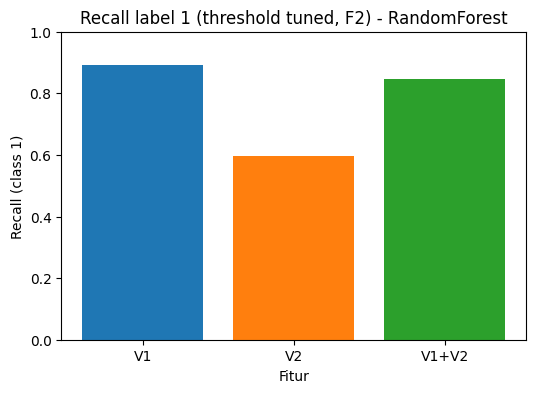

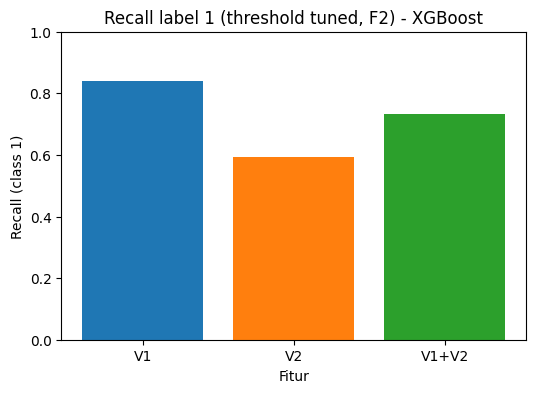

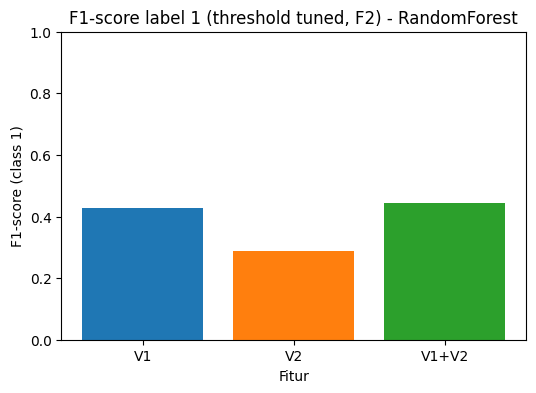

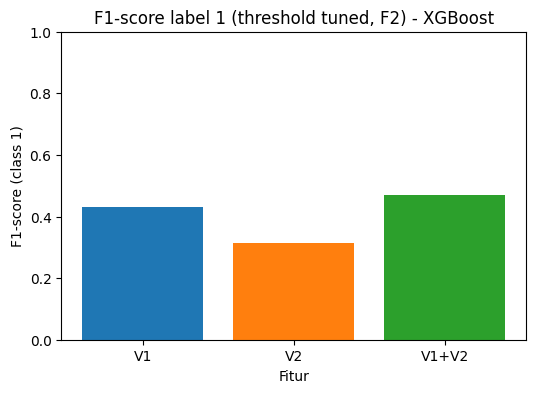

In [16]:
for model_name in results_df['model'].unique():
    sub = results_df[results_df['model'] == model_name]
    plt.figure(figsize=(6, 4))
    plt.bar(sub['features'], sub['recall1_tuned'], color=['tab:blue', 'tab:orange', 'tab:green'])
    plt.ylim(0, 1)
    plt.title(f'Recall label 1 (threshold tuned, F2) - {model_name}')
    plt.ylabel('Recall (class 1)')
    plt.xlabel('Fitur')
    plt.show()
    
for model_name in results_df['model'].unique():
    sub = results_df[results_df['model'] == model_name]
    plt.figure(figsize=(6, 4))
    plt.bar(sub['features'], sub['f1_1_tuned'], color=['tab:blue', 'tab:orange', 'tab:green'])
    plt.ylim(0, 1)
    plt.title(f'F1-score label 1 (threshold tuned, F2) - {model_name}')
    plt.ylabel('F1-score (class 1)')
    plt.xlabel('Fitur')
    plt.show()